<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

- Eduardo Montoya Guevara CC: 1035443241
- Katherine Narvaez CC:1040752246


Relacione sus datos y los del compañero de trabajo

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from scipy.stats import zscore

In [4]:
df = load_wine()
data = pd.DataFrame(df.data, columns=df.feature_names)
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [5]:
NUMERIC = ['alcohol', 'total_phenols', 'color_intensity']

**StandardScaler**: Transforma los datos para que tengan media 0 y desviación estándar 1, lo que es útil para algoritmos que asumen normalidad

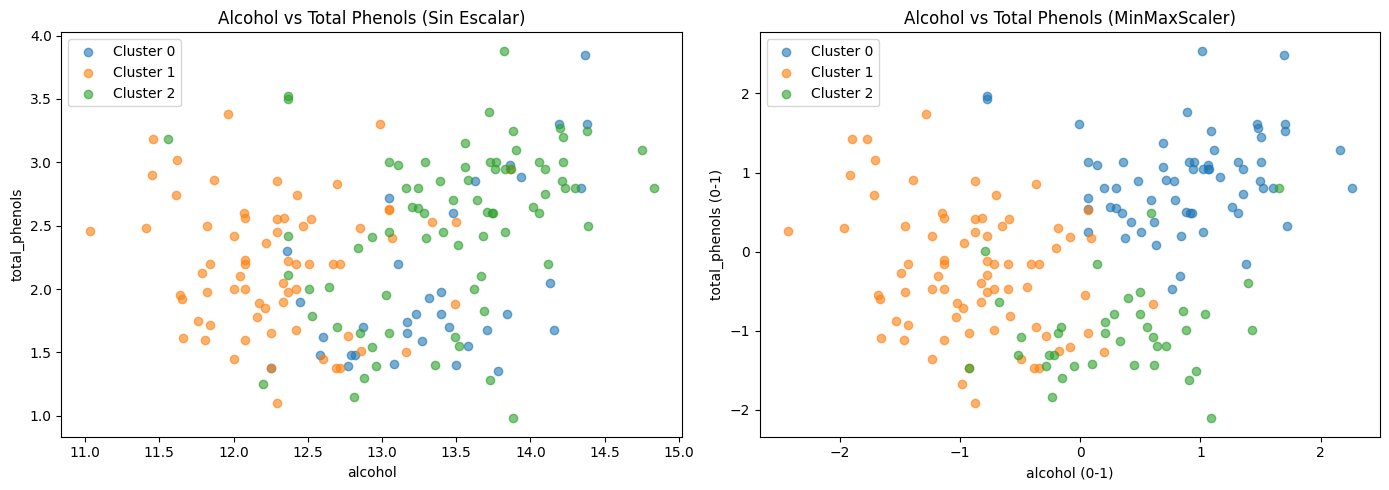

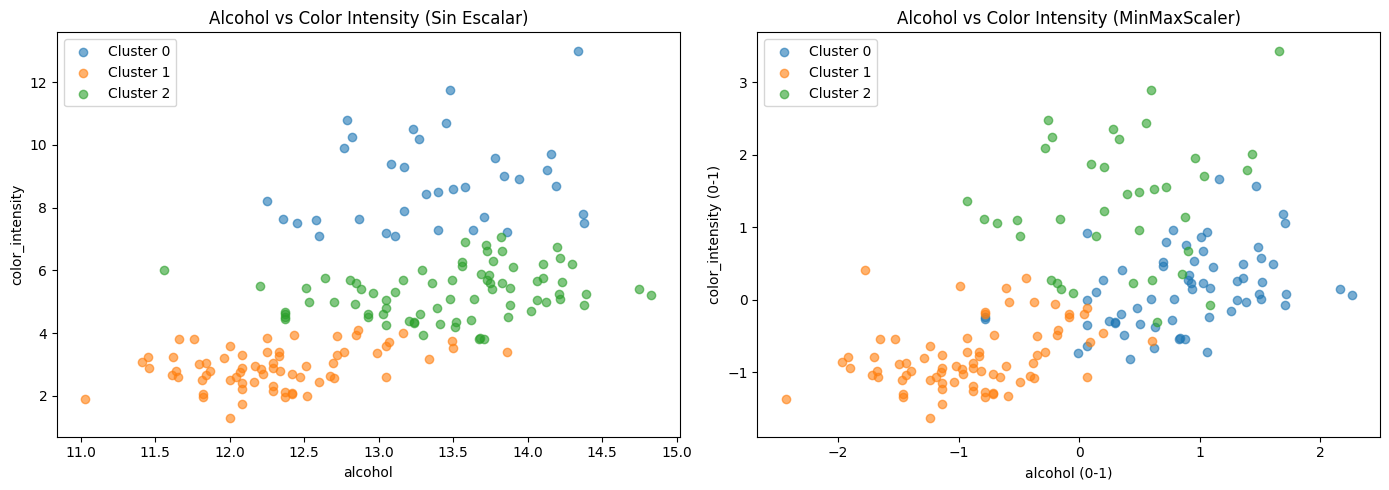

In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd

# 1. Preparación de datos y clusters
datos = data[NUMERIC].copy()
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos)

# Ejecutamos K-Means en ambos casos
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos)
kmeans_StandardScaler = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos_escalados)

colors = ['tab:blue', 'tab:orange', 'tab:green']

# --- FUNCIÓN AUXILIAR PARA NO REPETIR CÓDIGO ---
def graficar_comparativa(idx_x, idx_y, titulo_base):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    name_x = NUMERIC[idx_x]
    name_y = NUMERIC[idx_y]

    for i in range(3):
        # Gráfico Sin Escalar (Pandas .iloc)
        puntos_raw = datos[kmeans_raw.labels_ == i]
        axs[0].scatter(puntos_raw.iloc[:, idx_x], puntos_raw.iloc[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)
        
        # Gráfico Escalado (NumPy indices)
        puntos_scaled = datos_escalados[kmeans_StandardScaler.labels_ == i]
        axs[1].scatter(puntos_scaled[:, idx_x], puntos_scaled[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)

    # Formato
    axs[0].set_title(f'{titulo_base} (Sin Escalar)')
    axs[0].set_xlabel(name_x)
    axs[0].set_ylabel(name_y)
    
    axs[1].set_title(f'{titulo_base} (MinMaxScaler)')
    axs[1].set_xlabel(f'{name_x} (0-1)')
    axs[1].set_ylabel(f'{name_y} (0-1)')
    
    for ax in axs: ax.legend()
    plt.tight_layout()
    plt.show()

# --- GENERAR LAS DOS GRÁFICAS ---

# Gráfica 1: Alcohol (0) vs Total Phenols (1)
graficar_comparativa(0, 1, "Alcohol vs Total Phenols")

# Gráfica 2: Alcohol (0) vs Color Intensity (2)
graficar_comparativa(0, 2, "Alcohol vs Color Intensity")

**MinMaxScaler:** Escala los datos a un rango específico (generalmente entre 0 y 1), lo que es útil para algoritmos que requieren valores en un rango definido

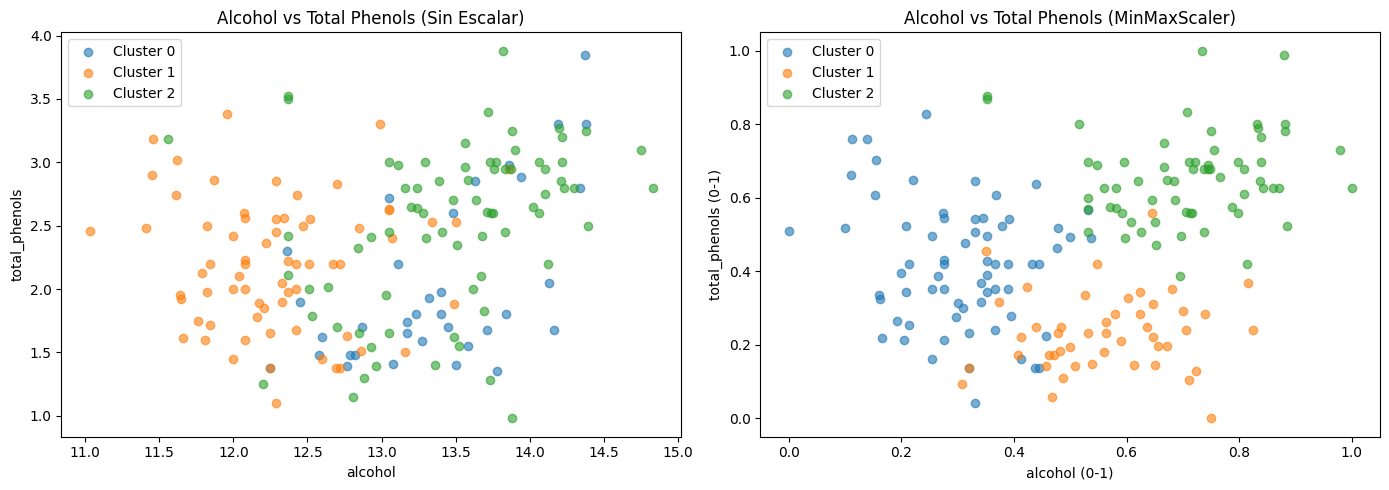

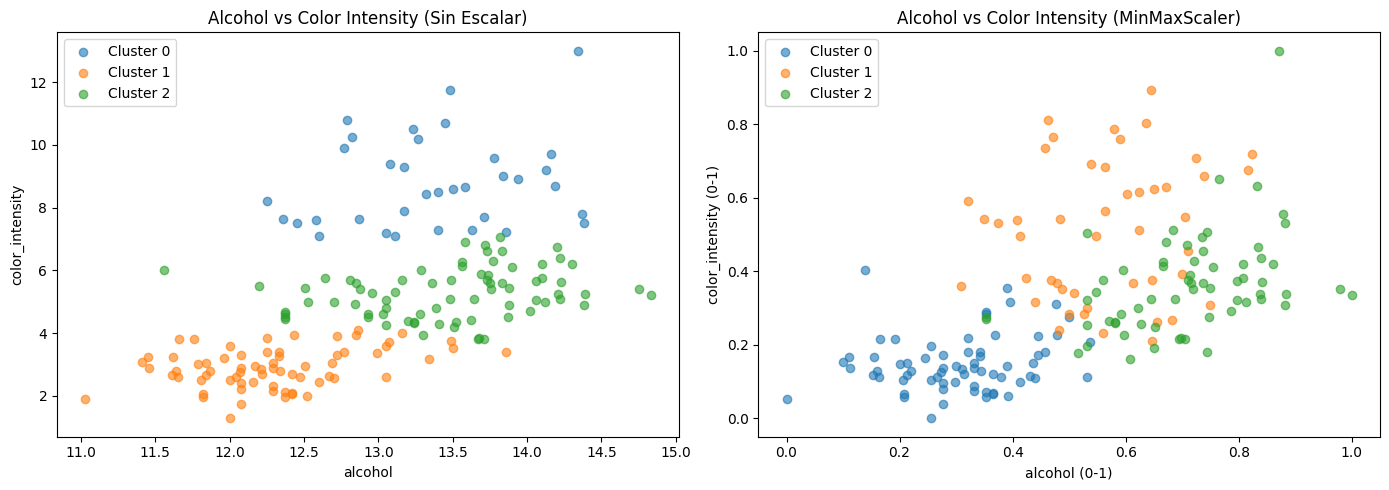

In [7]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd

# 1. Preparación de datos y clusters
datos = data[NUMERIC].copy()
scaler = MinMaxScaler()
datos_escalados = scaler.fit_transform(datos)

# Ejecutamos K-Means en ambos casos
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos)
kmeans_minmax = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos_escalados)

colors = ['tab:blue', 'tab:orange', 'tab:green']

# --- FUNCIÓN AUXILIAR PARA NO REPETIR CÓDIGO ---
def graficar_comparativa(idx_x, idx_y, titulo_base):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    name_x = NUMERIC[idx_x]
    name_y = NUMERIC[idx_y]

    for i in range(3):
        # Gráfico Sin Escalar (Pandas .iloc)
        puntos_raw = datos[kmeans_raw.labels_ == i]
        axs[0].scatter(puntos_raw.iloc[:, idx_x], puntos_raw.iloc[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)
        
        # Gráfico Escalado (NumPy indices)
        puntos_scaled = datos_escalados[kmeans_minmax.labels_ == i]
        axs[1].scatter(puntos_scaled[:, idx_x], puntos_scaled[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)

    # Formato
    axs[0].set_title(f'{titulo_base} (Sin Escalar)')
    axs[0].set_xlabel(name_x)
    axs[0].set_ylabel(name_y)
    
    axs[1].set_title(f'{titulo_base} (MinMaxScaler)')
    axs[1].set_xlabel(f'{name_x} (0-1)')
    axs[1].set_ylabel(f'{name_y} (0-1)')
    
    for ax in axs: ax.legend()
    plt.tight_layout()
    plt.show()

# --- GENERAR LAS DOS GRÁFICAS ---

# Gráfica 1: Alcohol (0) vs Total Phenols (1)
graficar_comparativa(0, 1, "Alcohol vs Total Phenols")

# Gráfica 2: Alcohol (0) vs Color Intensity (2)
graficar_comparativa(0, 2, "Alcohol vs Color Intensity")

**RobustScaler:** Escala los datos utilizando estadísticas robustas (mediana y rango intercuartílico), lo que es útil para datos con outliers

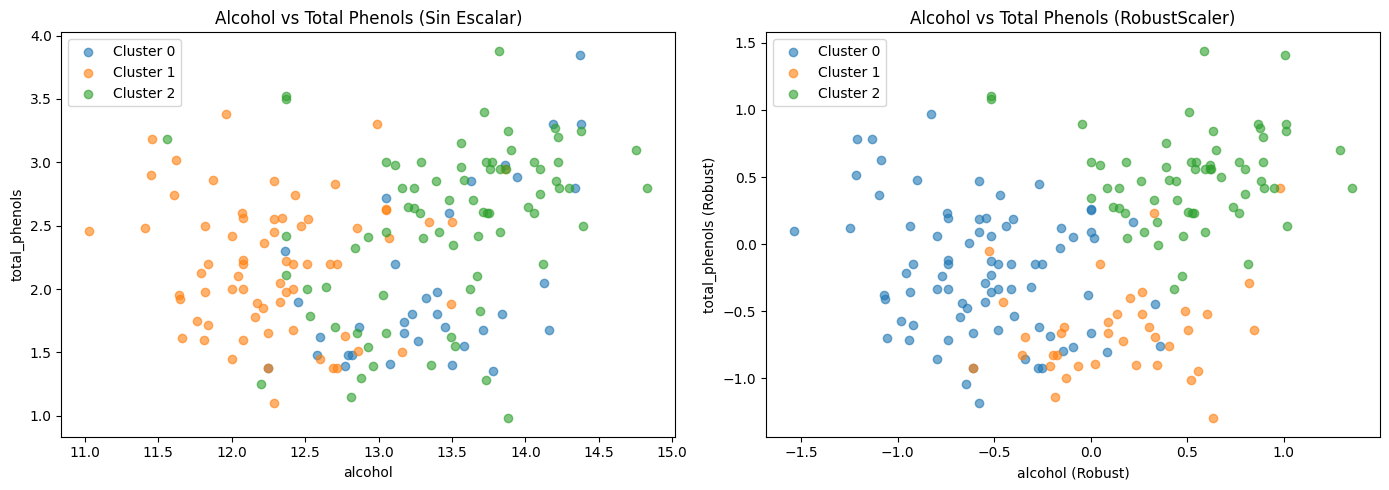

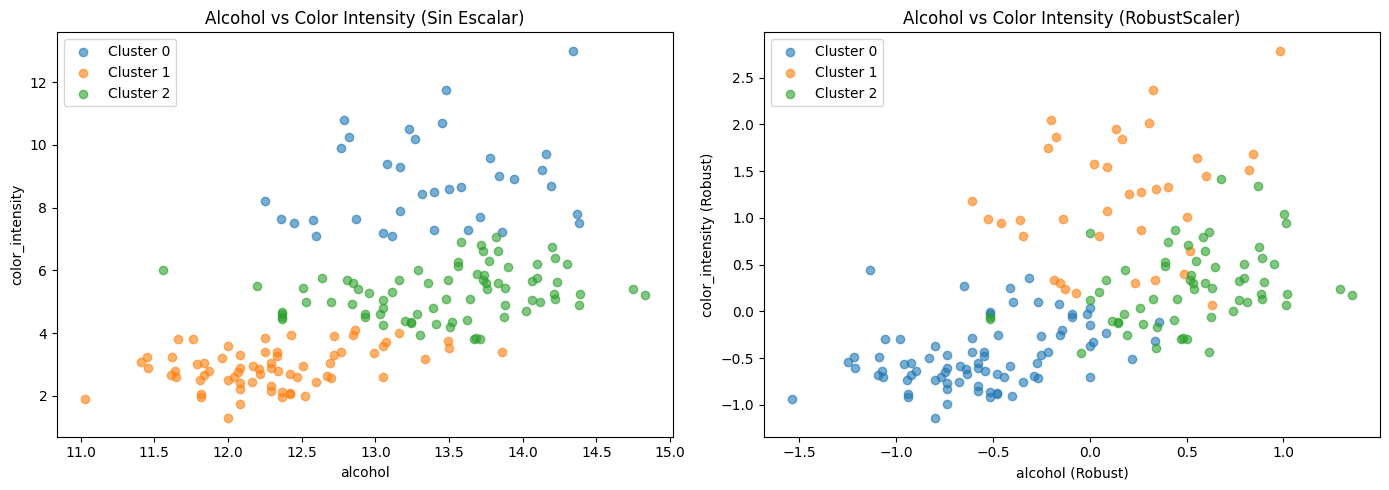

In [8]:
# 1. Preparación de datos
datos = data[NUMERIC].copy()
scaler_robust = RobustScaler()
datos_robust = scaler_robust.fit_transform(datos)

# K-Means para ambos casos
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos)
kmeans_robust = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos_robust)

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Función para graficar
def graficar_robust(idx_x, idx_y, titulo_base):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    name_x = NUMERIC[idx_x]
    name_y = NUMERIC[idx_y]

    for i in range(3):
        # Gráfico Sin Escalar (DataFrame)
        puntos_raw = datos[kmeans_raw.labels_ == i]
        axs[0].scatter(puntos_raw.iloc[:, idx_x], puntos_raw.iloc[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)
        
        # Gráfico con RobustScaler (NumPy Array)
        puntos_scaled = datos_robust[kmeans_robust.labels_ == i]
        axs[1].scatter(puntos_scaled[:, idx_x], puntos_scaled[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)

    axs[0].set_title(f'{titulo_base} (Sin Escalar)')
    axs[0].set_xlabel(name_x)
    axs[0].set_ylabel(name_y)
    
    axs[1].set_title(f'{titulo_base} (RobustScaler)')
    axs[1].set_xlabel(f'{name_x} (Robust)')
    axs[1].set_ylabel(f'{name_y} (Robust)')
    
    for ax in axs: ax.legend()
    plt.tight_layout()
    plt.show()

# --- GENERAR LAS GRÁFICAS ---

# Comparativa 1: Alcohol vs Total Phenols
graficar_robust(0, 1, "Alcohol vs Total Phenols")

# Comparativa 2: Alcohol vs Color Intensity
graficar_robust(0, 2, "Alcohol vs Color Intensity")

**Z-Score:** Similar a StandardScaler, pero se basa en la media y desviación estándar de la muestra, lo que puede ser útil para detectar outliers

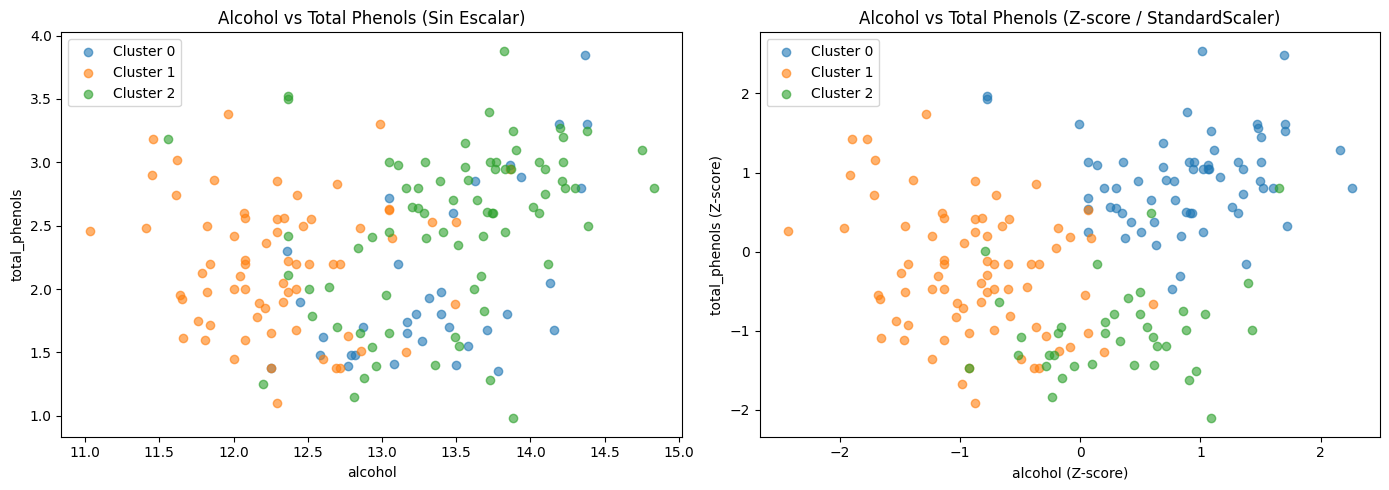

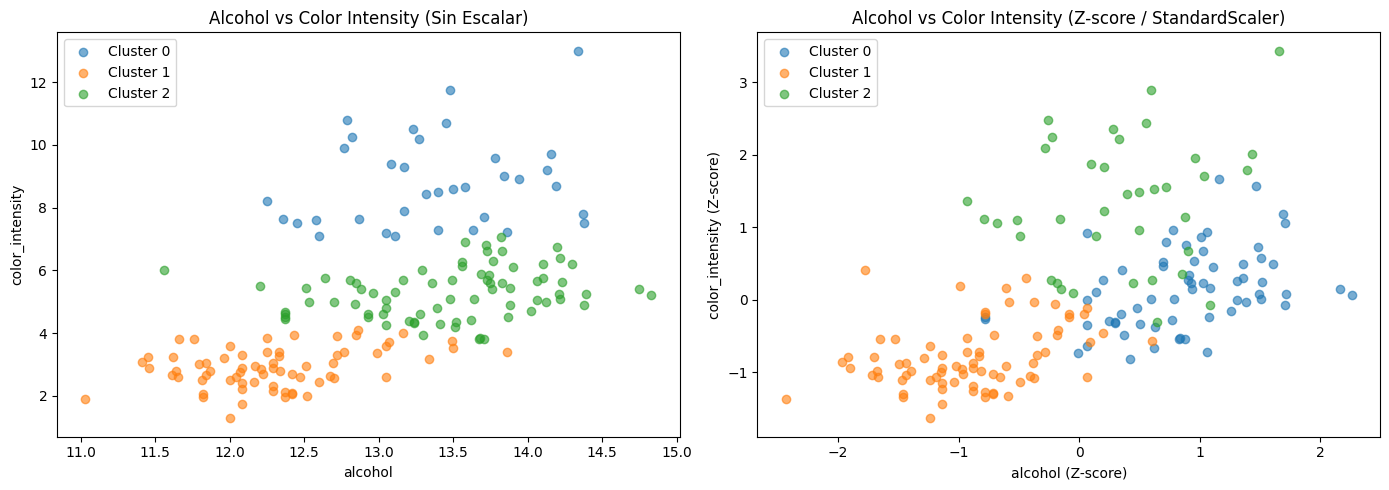

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Preparación de datos
datos = data[NUMERIC].copy()
scaler_z = StandardScaler()
datos_zscore = scaler_z.fit_transform(datos)

# K-Means para ambos casos (Sin escalar vs Z-score)
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos)
kmeans_zscore = KMeans(n_clusters=3, random_state=42, n_init=10).fit(datos_zscore)

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Función para graficar la comparativa
def graficar_comparativa_z(idx_x, idx_y, titulo_base):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    
    name_x = NUMERIC[idx_x]
    name_y = NUMERIC[idx_y]

    for i in range(3):
        # Gráfico Sin Escalar (usando .iloc para DataFrame)
        puntos_raw = datos[kmeans_raw.labels_ == i]
        axs[0].scatter(puntos_raw.iloc[:, idx_x], puntos_raw.iloc[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)
        
        # Gráfico con Z-score (usando índices directos para NumPy array)
        puntos_scaled = datos_zscore[kmeans_zscore.labels_ == i]
        axs[1].scatter(puntos_scaled[:, idx_x], puntos_scaled[:, idx_y], 
                       c=colors[i], label=f'Cluster {i}', alpha=0.6)

    # Configuración de títulos y etiquetas
    axs[0].set_title(f'{titulo_base} (Sin Escalar)')
    axs[0].set_xlabel(name_x)
    axs[0].set_ylabel(name_y)
    
    axs[1].set_title(f'{titulo_base} (Z-score / StandardScaler)')
    axs[1].set_xlabel(f'{name_x} (Z-score)')
    axs[1].set_ylabel(f'{name_y} (Z-score)')
    
    for ax in axs: ax.legend()
    plt.tight_layout()
    plt.show()

# --- GENERAR LAS DOS GRÁFICAS REQUERIDAS ---

# 1. Alcohol vs Total Phenols
graficar_comparativa_z(0, 1, "Alcohol vs Total Phenols")

# 2. Alcohol vs Color Intensity
graficar_comparativa_z(0, 2, "Alcohol vs Color Intensity")

**Comparación** entre todos los metodos

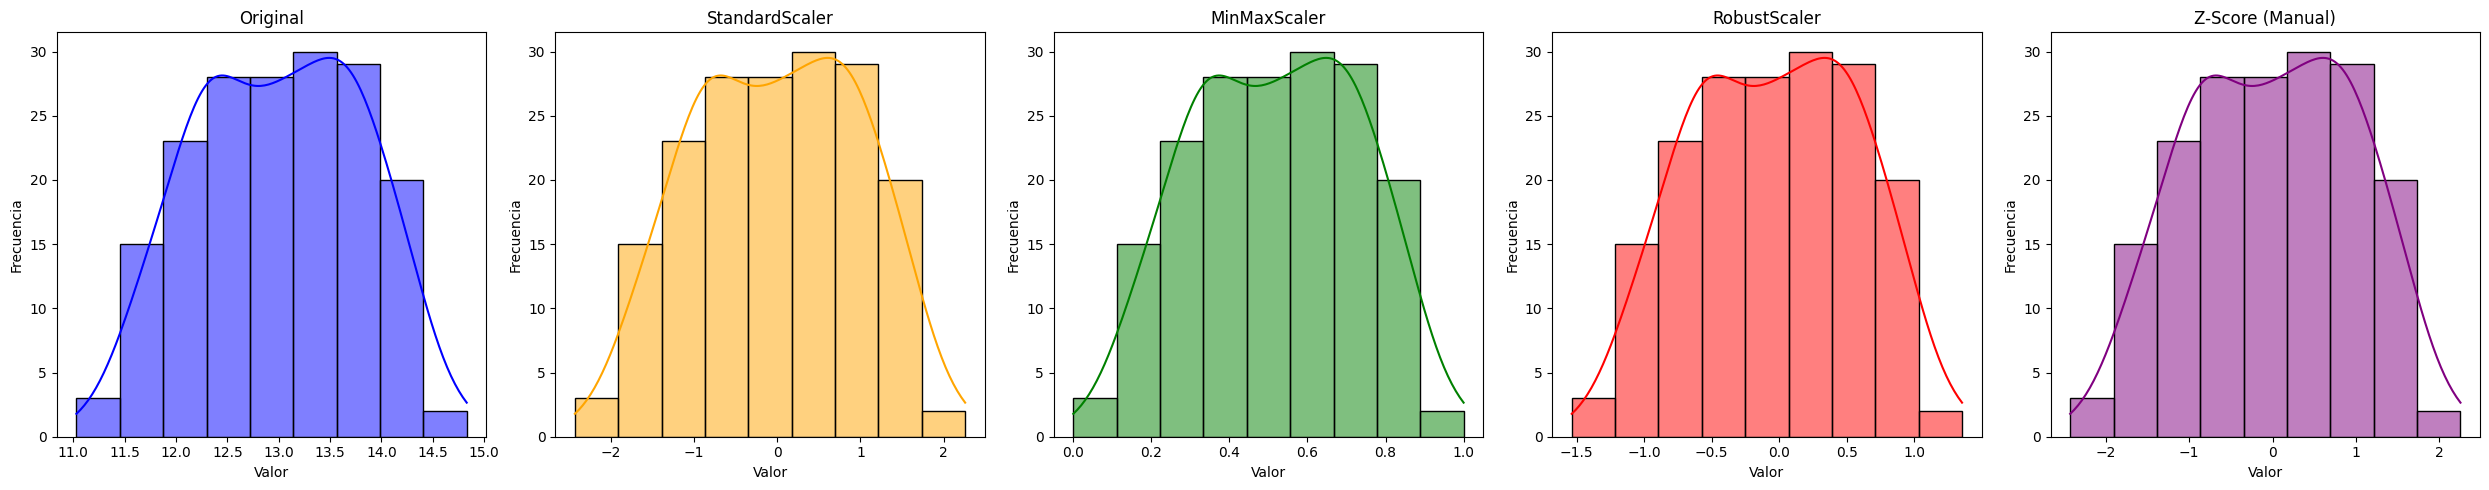

In [10]:
import seaborn as sns
# 1. Selección de la variable
variable = 'alcohol'
original = data[variable]

# 2. Aplicación de escaladores
# StandardScaler
ss = StandardScaler()
scaled_ss = ss.fit_transform(data[[variable]]).flatten()

# MinMaxScaler
mm = MinMaxScaler()
scaled_mm = mm.fit_transform(data[[variable]]).flatten()

# RobustScaler
rs = RobustScaler()
scaled_rs = rs.fit_transform(data[[variable]]).flatten()

# Z-Score (Cálculo manual: (x - media) / desviación estándar)

zscore_manual = (data[variable] - data[variable].mean()) / data[variable].std()

# 3. Visualización comparativa
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

titulos = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler', 'Z-Score (Manual)']
datos_plot = [original, scaled_ss, scaled_mm, scaled_rs, zscore_manual]
colores = ['blue', 'orange', 'green', 'red', 'purple']

for i in range(5):
    sns.histplot(datos_plot[i], kde=True, ax=axes[i], color=colores[i])
    axes[i].set_title(titulos[i])
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Analisis:** 
Las técnicas difieren en su base estadística: MinMaxScaler acota los datos a $[0, 1]$, mientras StandardScaler y RobustScaler se centran en la distribución (media vs. mediana), siendo este último superior ante valores atípicos. Su impacto en K-Means es crítico para igualar el peso de variables con magnitudes distintas, evitando que escalas grandes dominen el agrupamiento. Recomiendo StandardScaler (Z-score) para este dataset, ya que las variables del vino suelen ser continuas y sin valores atípicos extremos, permitiendo una partición de clusters más equilibrada.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

**Características del dataset diabetes:**

In [11]:

from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

# 2. Convertir en DataFrame e identificar variables
data_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
print("Columnas disponibles:", data_diabetes.columns)
data_diabetes.head()


Columnas disponibles: Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641



3. Seleccionar tres variables numéricas

bmi: Body mass index

bp: Average blood pressure

s5: Lamotrigine (Gluconeogenesis-related blood measure)

In [12]:
numeric_diabetes = ['bmi', 'bp', 's5']
datos_selected = data_diabetes[numeric_diabetes]

In [13]:
# 4. Aplicar métodos de escalamiento
# StandardScaler (Z-Score)
ss_diabetes = StandardScaler()
scaled_zscore_diabetes = ss_diabetes.fit_transform(datos_selected)

# RobustScaler (Mediana e IQR)
rs_diabetes = RobustScaler()
scaled_robust_diabetes = rs_diabetes.fit_transform(datos_selected)

# Save for plotting later
scaled_zscore_df = pd.DataFrame(scaled_zscore_diabetes, columns=numeric_diabetes)
scaled_robust_df = pd.DataFrame(scaled_robust_diabetes, columns=numeric_diabetes)


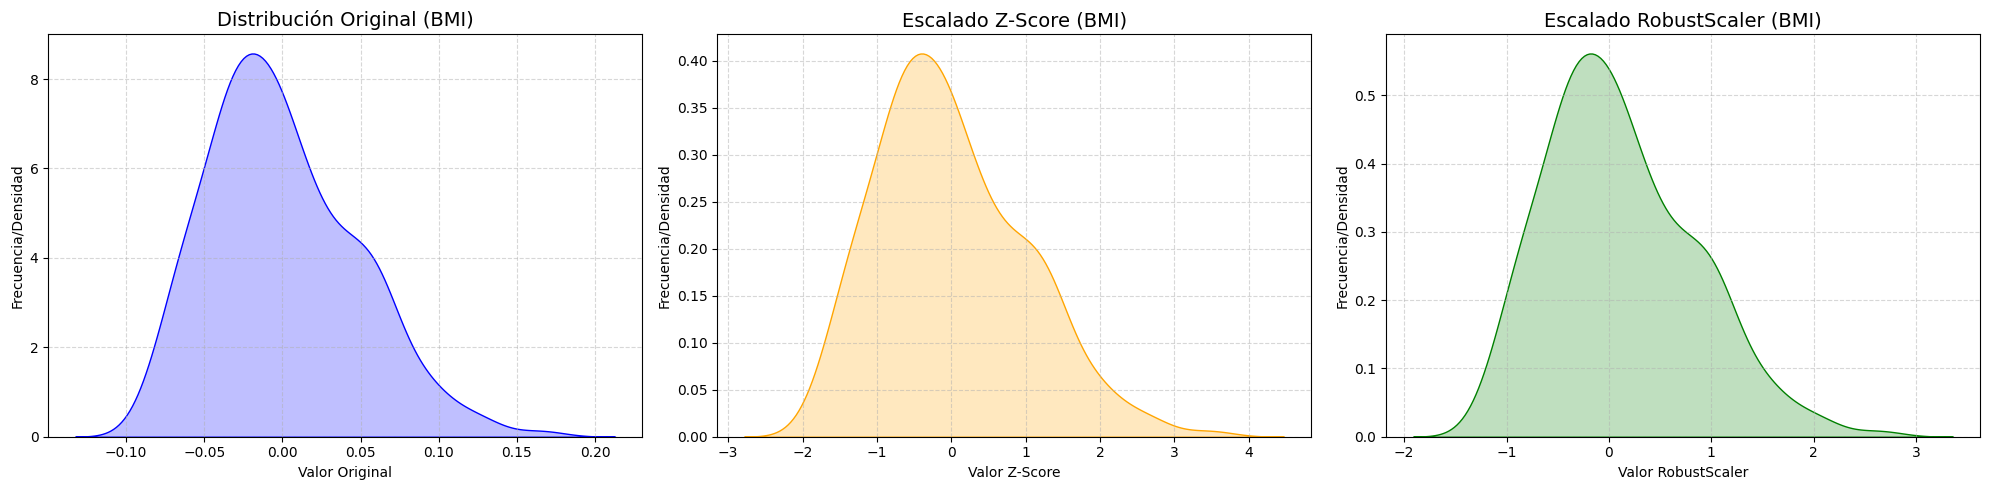

In [14]:
# 5. Generar gráficas comparativas
variable_plot_diabetes = 'bmi'

fig_diabetes, axes_diabetes = plt.subplots(1, 3, figsize=(20, 5))

# Plotting with original data
# BMI: Body mass index
axes_diabetes[0].set_title(f'Distribución Original ({variable_plot_diabetes.upper()})', fontsize=14)
sns.kdeplot(datos_selected[variable_plot_diabetes], fill=True, ax=axes_diabetes[0], color='blue')
axes_diabetes[0].set_xlabel('Valor Original')
axes_diabetes[0].set_ylabel('Frecuencia/Densidad')
axes_diabetes[0].grid(True, linestyle='--', alpha=0.5)

# Plotting with Z-Score scaled data
axes_diabetes[1].set_title(f'Escalado Z-Score ({variable_plot_diabetes.upper()})', fontsize=14)
sns.kdeplot(scaled_zscore_df[variable_plot_diabetes], fill=True, ax=axes_diabetes[1], color='orange')
axes_diabetes[1].set_xlabel('Valor Z-Score')
axes_diabetes[1].set_ylabel('Frecuencia/Densidad')
axes_diabetes[1].grid(True, linestyle='--', alpha=0.5)

# Plotting with RobustScaler scaled data
axes_diabetes[2].set_title(f'Escalado RobustScaler ({variable_plot_diabetes.upper()})', fontsize=14)
sns.kdeplot(scaled_robust_df[variable_plot_diabetes], fill=True, ax=axes_diabetes[2], color='green')
axes_diabetes[2].set_xlabel('Valor RobustScaler')
axes_diabetes[2].set_ylabel('Frecuencia/Densidad')
axes_diabetes[2].grid(True, linestyle='--', alpha=0.5)

# Show plots
plt.tight_layout()
plt.savefig('comparativa_distribuciones_diabetes.png')

**Analisis:** El escalamiento Z-Score estandariza los datos basándose en la media y desviación estándar, mientras que RobustScaler utiliza la mediana y el rango intercuartílico, lo que lo hace menos sensible a valores atípicos. En el dataset de diabetes, los gráficos muestran que la forma de la distribución se mantiene, pero los rangos cambian: RobustScaler tiende a comprimir más los valores cercanos al centro. Considero RobustScaler más recomendable para este conjunto de datos, ya que presenta varios valores atípicos visibles en el BMI que podrían sesgar la media en el cálculo del Z-Score.

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

**Carga de satos de California Housing:**

In [15]:

from sklearn.preprocessing import Normalizer
from sklearn.datasets import fetch_california_housing
# 1. Load the California Housing dataset
housing = fetch_california_housing()

# 2. Convert to pandas DataFrame and identify variables
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
print("Variables disponibles en California Housing:")
print(df_housing.columns.tolist())
print("\nPrimeras filas del dataset:")
df_housing.head()

Variables disponibles en California Housing:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Primeras filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [16]:
selected_vars = ['MedInc', 'AveRooms', 'Population']
df_selected = df_housing[selected_vars].copy()

# 4. Apply Normalization methods using Normalizer (Row-wise scaling)
# Note: sklearn.preprocessing.Normalizer scales each SAMPLE (row) to have unit norm.
# It does NOT scale the columns individually.

# Apply L1 Normalization
transformer_l1 = Normalizer(norm='l1')
data_l1 = transformer_l1.fit_transform(df_selected)
#df_l1 = pd.DataFrame(data_l1, columns=selected_vars)

# Apply L2 Normalization
transformer_l2 = Normalizer(norm='l2')
data_l2 = transformer_l2.fit_transform(df_selected)
#df_l2 = pd.DataFrame(data_l2, columns=selected_vars)

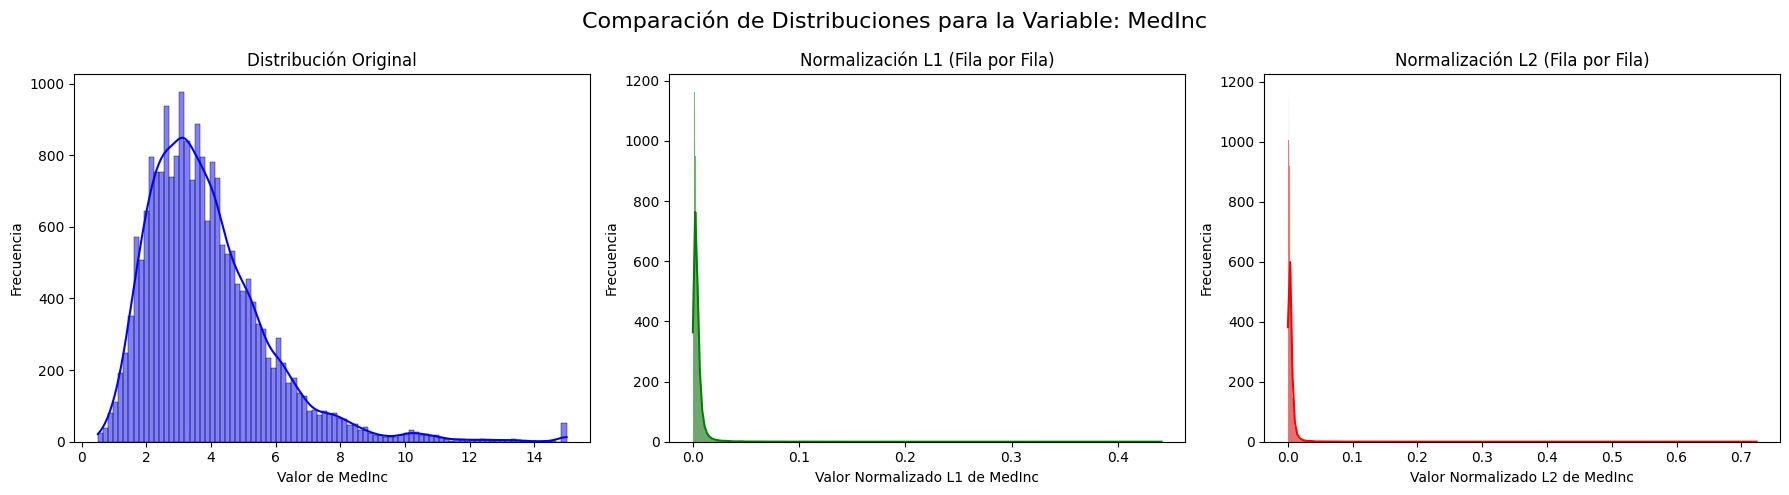

In [17]:
# 5. Generate comparative plots for 'MedInc'
variable_to_plot = 'MedInc'

# Set up the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Comparación de Distribuciones para la Variable: {variable_to_plot}', fontsize=16)

# Plot 1: Original Distribution
sns.histplot(df_selected[variable_to_plot], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribución Original')
axes[0].set_xlabel(f'Valor de {variable_to_plot}')
axes[0].set_ylabel('Frecuencia')

# Plot 2: L1 Normalized Distribution
sns.histplot(data_l1[:, selected_vars.index(variable_to_plot)], kde=True, ax=axes[1], color='green')
axes[1].set_title('Normalización L1 (Fila por Fila)')
axes[1].set_xlabel(f'Valor Normalizado L1 de {variable_to_plot}')
axes[1].set_ylabel('Frecuencia')

# Plot 3: L2 Normalized Distribution
sns.histplot(data_l2[:, selected_vars.index(variable_to_plot)], kde=True, ax=axes[2], color='red')
axes[2].set_title('Normalización L2 (Fila por Fila)')
axes[2].set_xlabel(f'Valor Normalizado L2 de {variable_to_plot}')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()

**Analisis:**
La normalización L1 normaliza cada fila de modo que la suma de sus valores absolutos sea 1, mientras que L2 lo hace de modo que la suma de sus cuadrados sea 1. Como se observa en los gráficos, L1 tiende a concentrar más los datos hacia el cero en este dataset. Para el agrupamiento o visualización de viviendas, L2 es más recomendable, ya que preserva mejor la forma y la variación relativa de las características originales dentro de cada muestra, evitando la acumulación excesiva cerca de cero vista en L1.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

**Carga de los datos y asignacion de variable** 

In [27]:
from scipy import stats
# 1. Cargar el conjunto de datos (usamos scaled=False para tener valores originales positivos)
diabetes_raw = load_diabetes(scaled=False)
df_diabetes = pd.DataFrame(diabetes_raw.data, columns=diabetes_raw.feature_names)

numeric_diabetes = ['bmi', 's5']
datos_selected = df_diabetes[numeric_diabetes]

In [30]:
# 3. Aplicar transformaciones

data_orig = datos_selected['s5']  # Variable original para comparativa
# Logarítmica (usamos log1p por seguridad aunque sean positivos)
data_log = np.log1p(datos_selected['s5'])

# Logarítmica Reflejada (Constante + 1 - x)
# Se usa para convertir asimetría negativa en positiva antes del logaritmo
data_ref_log = np.log1p(datos_selected['s5'].max() + 1 - datos_selected['s5'])

# Cuadrática
data_quad = np.square(datos_selected['s5'])

# Box-Cox (requiere datos estrictamente positivos)
data_boxcox, lam = stats.boxcox(datos_selected['s5'])

        bmi        s5
0  0.061696  0.019907
1 -0.051474 -0.068332
2  0.044451  0.002861
3 -0.011595  0.022688
4 -0.036385 -0.031988


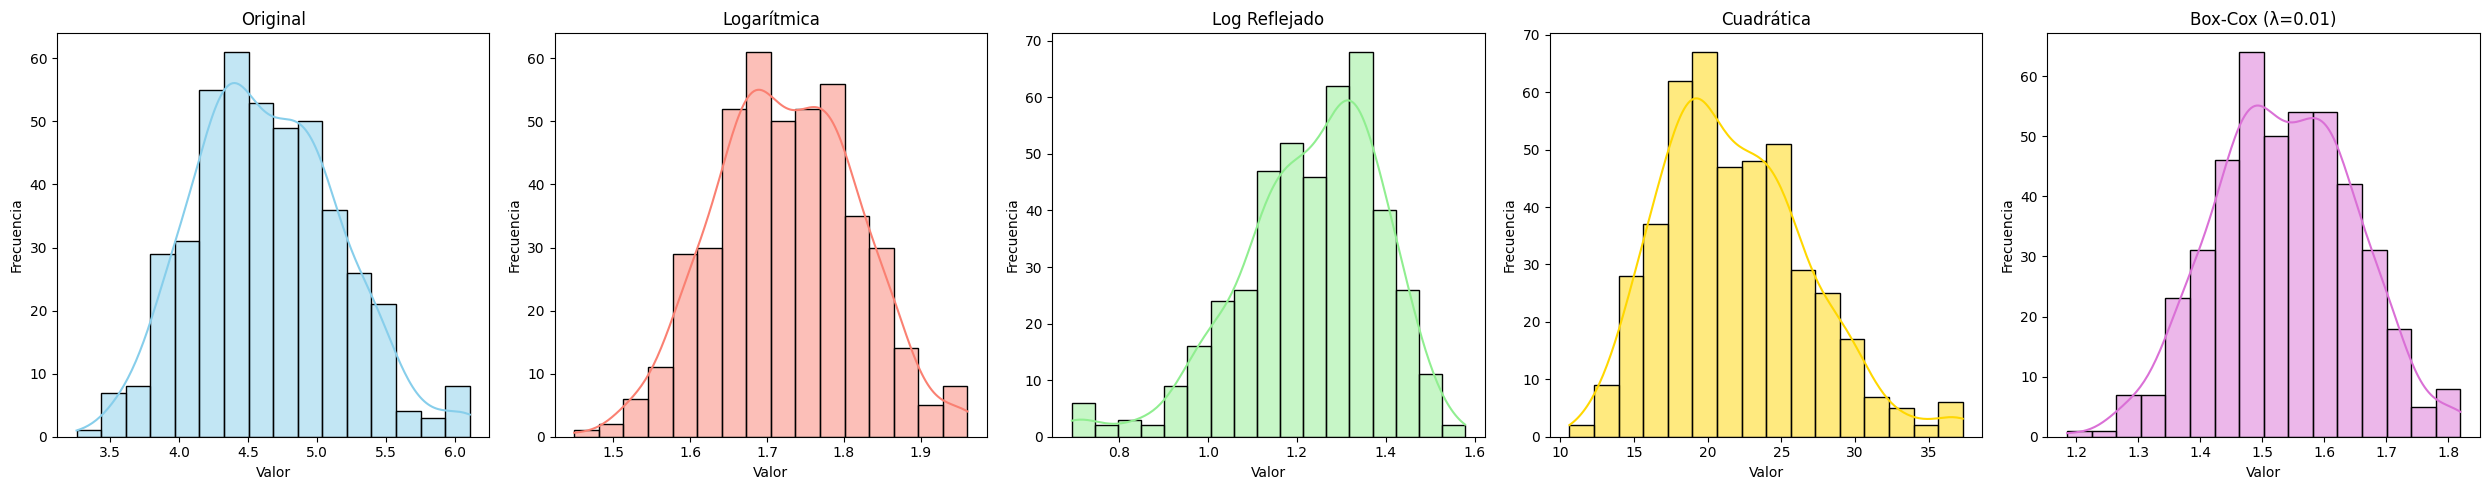

In [32]:
# 4. Generación de gráficas
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

transformaciones = [
    (data_orig, 'Original', 'skyblue'),
    (data_log, 'Logarítmica', 'salmon'),
    (data_ref_log, 'Log Reflejado', 'lightgreen'),
    (data_quad, 'Cuadrática', 'gold'),
    (data_boxcox, f'Box-Cox (λ={lam:.2f})', 'orchid')
]

for i, (data_t, title, color) in enumerate(transformaciones):
    sns.histplot(data_t, kde=True, ax=axes[i], color=color)
    axes[i].set_title(title)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()

# Mostrar las primeras filas del DF para el usuario
print(df[['bmi', 's5']].head())

**Analisis:**
Las técnicas logarítmicas y Box-Cox son efectivas para reducir la asimetría positiva, mientras que la cuadrática la acentúa, siendo útil solo en casos de asimetría negativa. La transformación reflejada permite aplicar logaritmos a datos con sesgo a la izquierda, pero en este dataset no es necesaria. Considero Box-Cox como la más recomendable, ya que ajusta matemáticamente el parámetro $\lambda$ para maximizar la normalidad de los datos, lo cual es fundamental para el éxito de muchos modelos estadísticos y de regresión.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [36]:
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import PowerTransformer

# 1. Carga del conjunto de datos
heart_disease = fetch_ucirepo(id=45)

# 2. Conversión a DataFrame e identificación de variables
X = heart_disease.data.features
y = heart_disease.data.targets
df = pd.DataFrame(X, columns=heart_disease.data.feature_names)

# 3. Selección de variables numéricas (usaremos 'chol' por su asimetría típica)
# Otras opciones: 'trestbps', 'thalach'
var_analisis = 'chol'
data_original = df[var_analisis].dropna() # Eliminamos nulos para las transformaciones

In [37]:
# 4. Aplicación de transformaciones
# Raíz cuadrada
data_sqrt = np.sqrt(data_original)

# Recíproca
data_reciprocal = 1 / data_original

# Yeo-Johnson (requiere reshape para Scikit-Learn)
pt = PowerTransformer(method="yeo-johnson")
data_yeo = pt.fit_transform(data_original.values.reshape(-1, 1)).flatten()

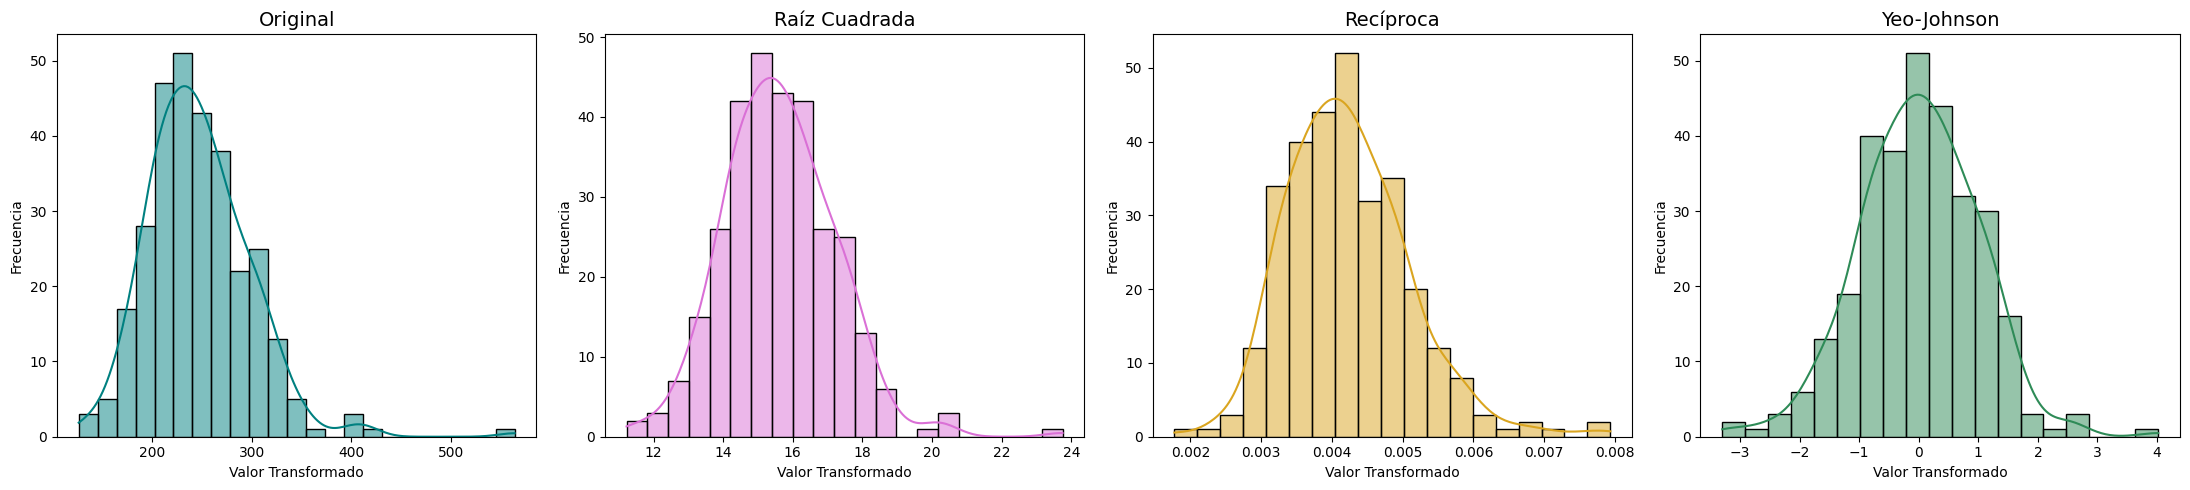

In [38]:
# 5. Generación de gráficas comparativas
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Configuración de los escenarios
titulos = ['Original', 'Raíz Cuadrada', 'Recíproca', 'Yeo-Johnson']
datasets = [data_original, data_sqrt, data_reciprocal, data_yeo]
colores = ['teal', 'orchid', 'goldenrod', 'seagreen']

for i in range(4):
    sns.histplot(datasets[i], kde=True, ax=axes[i], color=colores[i])
    axes[i].set_title(titulos[i], fontsize=14)
    axes[i].set_xlabel('Valor Transformado')
    axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

**Análisis:**

La raíz cuadrada suaviza la asimetría moderada, mientras que la recíproca invierte la escala y puede ser demasiado agresiva para variables clínicas como el colesterol. Yeo-Johnson destaca por su capacidad de ajustar automáticamente el parámetro de potencia para normalizar los datos, incluso con valores complejos. Considero Yeo-Johnson como la más recomendable, ya que estabiliza la varianza de forma más robusta y sistemática, optimizando la distribución para cumplir con los supuestos de modelos estadísticos avanzados.